<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>
<center><b><h1>Mansi Fatepara</b></center>    
    <center><b><h1>23010101079</b></center>    
<center><b><h1>Task - 1 & 2</b></center>    
<pre>    

<h1>Task_1
02/12/2025</h1>

## Read the Dataset and import libraries.

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

## Read the row data

In [48]:
df = pd.read_csv("cardio_train.csv",sep=";")
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


### Inspect Data Structure and Missing Values

In [49]:
print(df.head())

   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


### Drop Irrelevant ID Column

In [50]:
df.drop('id',axis=1,errors='ignore',inplace=True)

In [51]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


### check for duplicate value

In [53]:
duplicates = df.duplicated()
# duplicates
duplicates.sum()

np.int64(24)

### Remove Duplicates

In [54]:
df_unique = df.drop_duplicates()
df_unique

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


### Convert Age to Years

In [55]:
df_unique['age'] = df_unique['age']//365
df_unique

C:\Users\Admin\AppData\Local\Temp\ipykernel_12012\4007705081.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['age'] = df_unique['age']//365


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,2,168,76.0,120,80,1,1,1,0,1,0
69996,61,1,158,126.0,140,90,2,2,0,0,1,1
69997,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,61,1,163,72.0,135,80,1,2,0,0,0,1


### Checking if there are null values present in the dataset.

In [56]:
df_unique.isnull().sum()

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

### Summary of Numerical Data

In [57]:
df_unique.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000,69976.000000
mean,52.840874,1.349648,164.359152,74.208519,128.820453,96.636261,1.366997,1.226535,0.088159,0.053790,0.803718,0.499771
std,6.767103,0.476862,8.211218,14.397211,154.037729,188.504581,0.680333,0.572353,0.283528,0.225604,0.397187,0.500004
min,29.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


### Adding a BMI column in the dataset

In [58]:
# converts the height from centimeters to meters (m)
df_unique['bmi'] = df_unique['weight']/(df_unique['height']/100)**2

C:\Users\Admin\AppData\Local\Temp\ipykernel_12012\3685610697.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['bmi'] = df_unique['weight']/(df_unique['height']/100)**2


### What is the number of rows in the dataset?

In [59]:
df_unique.shape[0]

69976

### What is the number of columns in the dataset?

In [60]:
df_unique.shape[1]

13

### A boxplot can also be used to show the distribution of values for each attribute.

### plot a boxplot for height and weight

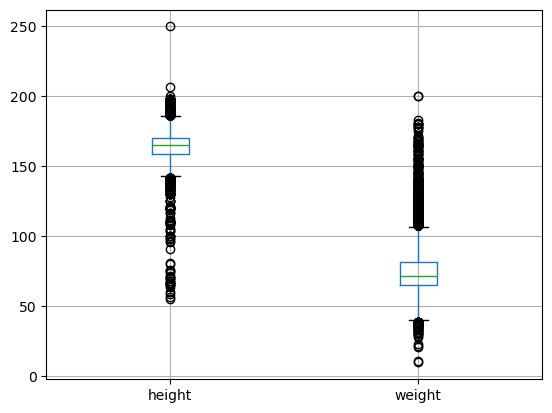

In [61]:
import matplotlib.pyplot as plt

df_unique[['height','weight']].boxplot()
plt.show()

### How is the dataset indexed?

In [62]:
df_unique.index

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       69990, 69991, 69992, 69993, 69994, 69995, 69996, 69997, 69998, 69999],
      dtype='int64', length=69976)

### Display scatter plot for any 5 pair of attributes , we can use a scatter plot to visualize their joint distribution.

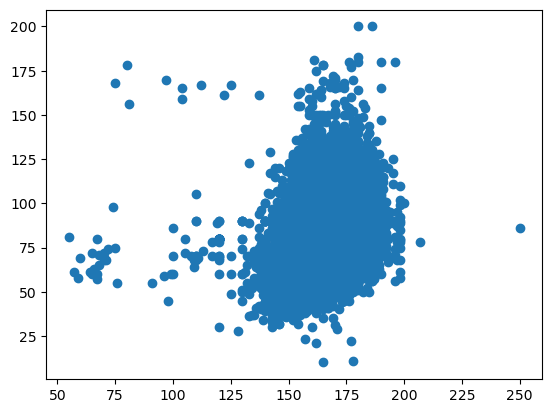

In [63]:
import matplotlib.pyplot as plt
x=df_unique['height']
y=df_unique['weight']
plt.scatter(x,y)
plt.show()

### Access rows by their integer locations

In [64]:
#iloc means integeer location and this is used for access rows and columns by their integer position.
df_unique.iloc[0]

age             50.00000
gender           2.00000
height         168.00000
weight          62.00000
ap_hi          110.00000
ap_lo           80.00000
cholesterol      1.00000
gluc             1.00000
smoke            0.00000
alco             0.00000
active           1.00000
cardio           0.00000
bmi             21.96712
Name: 0, dtype: float64

### Display the histogram for Age attribute by discretizing it into 8 separate bins and counting the frequency for each bin.

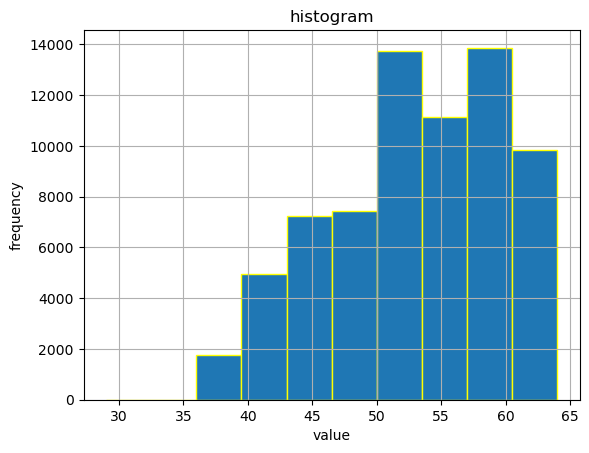

In [65]:
df_unique['age'].hist(bins = 10, edgecolor = 'yellow')
plt.xlabel('value')
plt.ylabel('frequency')
plt.title('histogram')
plt.show()

### Print the name of all columns

In [66]:
df_unique.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi'],
      dtype='object')

### What is the most frequent age?

In [67]:
df_unique['age'].value_counts().head(1)

age
55    3926
Name: count, dtype: int64

### Which is the age with least accurance?

In [68]:
df_unique['age'].value_counts().tail(1)

age
30    1
Name: count, dtype: int64

### Detect Outliers

In [88]:
# 5 number summary
# Method to handle outliers: IQR(Interquartile Range),Boxplot
import seaborn as sns
import matplotlib.pyplot as plt

numeric_value = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']


for col in numeric_value:
    Q1 = df_unique[col].quantile(0.25)
    Q3 = df_unique[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df_unique[(df_unique[col] < lower_limit) | (df_unique[col] > upper_limit)]
    print(f"{col} --> Outliers found: {outliers.shape[0]}")

age --> Outliers found: 4
height --> Outliers found: 519
weight --> Outliers found: 1819
ap_hi --> Outliers found: 1435
ap_lo --> Outliers found: 4632


### Remove Outliers

In [99]:
df_clean = df_unique.copy()

for col in numeric_value:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]
    
print("Original rows:", df_unique.shape[0])
print("After outlier removal:", df_clean.shape[0])


Original rows: 69976
After outlier removal: 62478


In [100]:
df_clean.shape[0]

62478

### scale numeric features

In [102]:
# perform min-mix scaller so we can convert our data into 0 to 1 range
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_value = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

df_unique[numeric_value] = scaler.fit_transform(df_unique[numeric_value])
df_unique[numeric_value]

,age,height,weight,ap_hi,ap_lo
0,0.600000,0.579487,0.273684,0.016079,0.013550
1,0.742857,0.517949,0.394737,0.017934,0.014453
2,0.628571,0.564103,0.284211,0.017316,0.012647
3,0.542857,0.584615,0.378947,0.018553,0.015357
4,0.514286,0.517949,0.242105,0.015461,0.011743
...,...,...,...,...,...
69995,0.657143,0.579487,0.347368,0.016698,0.013550
69996,0.914286,0.528205,0.610526,0.017934,0.014453
69997,0.657143,0.656410,0.500000,0.020408,0.014453
69998,0.914286,0.553846,0.326316,0.017625,0.013550


### display graphs

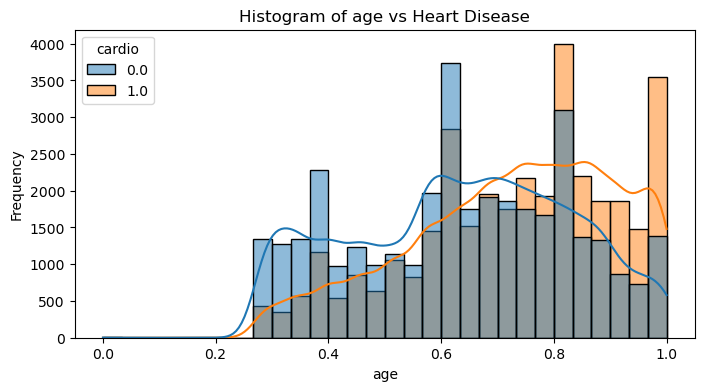

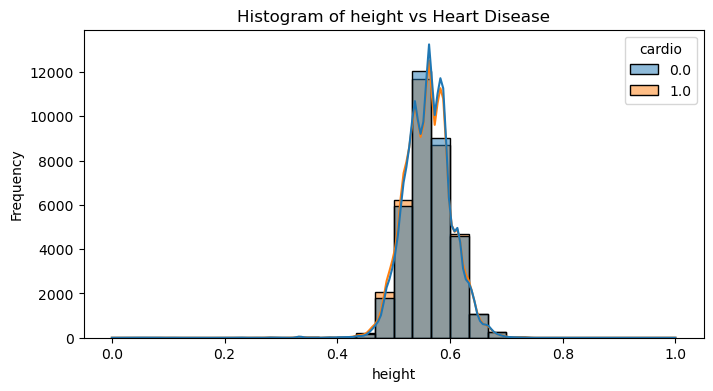

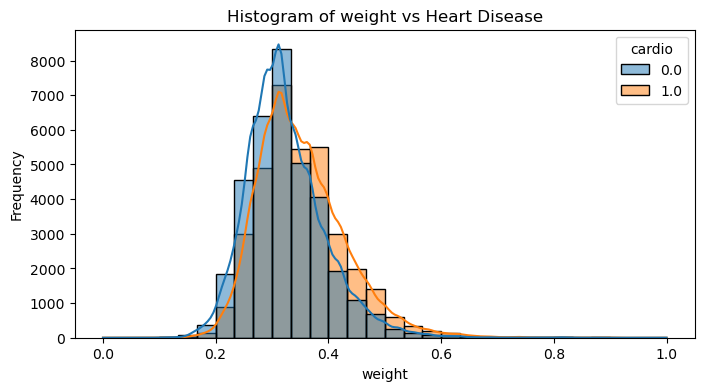

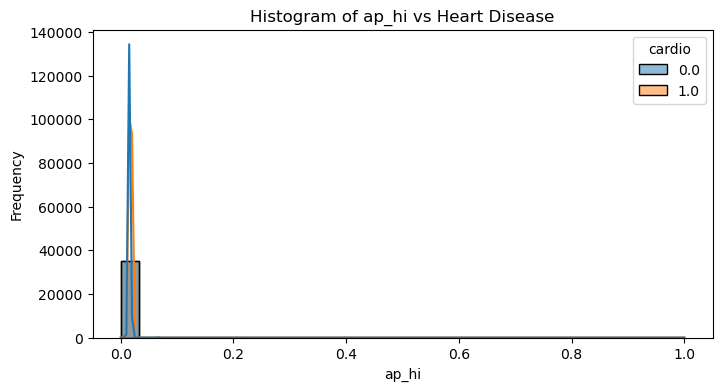

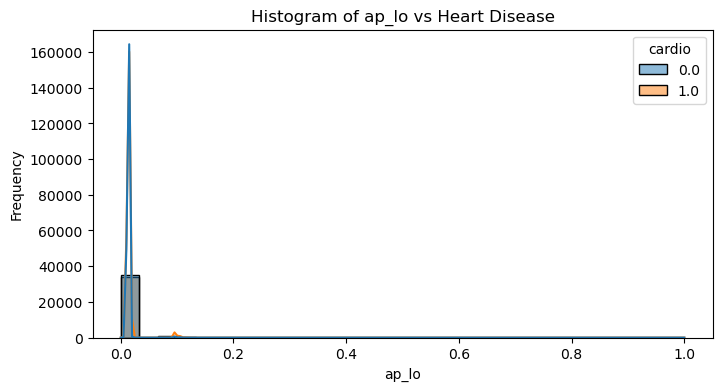

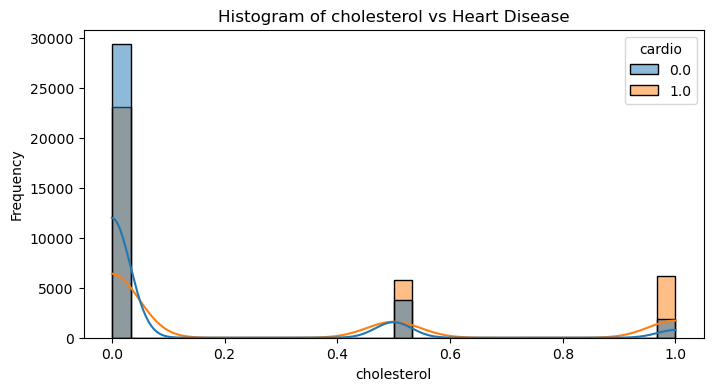

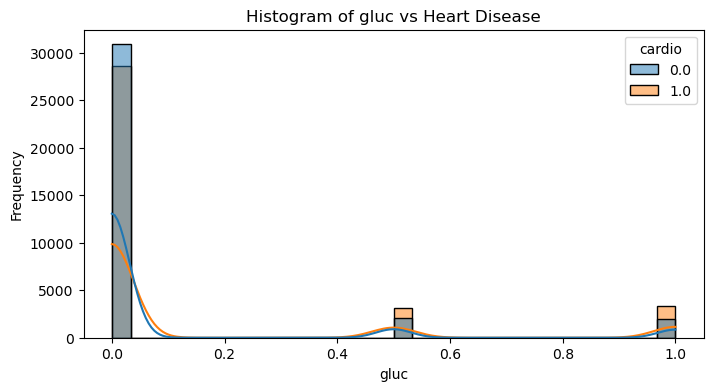

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['age','height','weight','ap_hi','ap_lo','cholesterol','gluc']

for col in features:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df_unique, x=col, hue='cardio', kde=True, bins=30) #kde use for smooth curve and hue is used for categorical column,spliting
    plt.title(f"Histogram of {col} vs Heart Disease")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [104]:
df_clean.to_csv("cardio_preprocessed.csv", index=False)